In [ ]:
%load_ext autoreload
%autoreload 2

In [ ]:
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

%config InlineBackend.figure_formats = {"retina", "png"}

# Suppress all pandas PerformanceWarnings
warnings.simplefilter(action="ignore", category=pd.errors.PerformanceWarning)
warnings.simplefilter(action="ignore", category=FutureWarning)

## Load LF + TSA merged dataset

The `scripts/bus39/transform.py` script produces merged LF+TSA dataset. Let's load the data.


In [ ]:
PROJECT_PATH = Path(".").resolve().parent
DATA_INTERIM_PATH = PROJECT_PATH / "data" / "bus39" / "interim"

assert DATA_INTERIM_PATH.exists(), DATA_INTERIM_PATH

In [ ]:
from src.utils import determine_features_and_targets

df = pd.read_pickle(DATA_INTERIM_PATH / "lf_tsa_merged.pkl")
feature_cols, target_cols = determine_features_and_targets(df)

In [ ]:
df.info()

<class 'pandas.DataFrame'>
Index: 1044797 entries, 0 to 1274688
Columns: 228 entries, state to Sk_Bus_39[MVA]
dtypes: bool[pyarrow](44), category(3), double[pyarrow](174), int64[pyarrow](7)
memory usage: 1.4 GB


In [ ]:
# Arbitrary value set by domain experts
CCT_THRESHOLD = 0.2

## CCT Estimation with Machine Learning


In [ ]:
import joblib
from sklearn import compose, neighbors
from sklearn import preprocessing as prep

from src.utils import TimeIt, select_centered_columns, select_positive_columns

In [ ]:
encoder = compose.make_column_transformer(
    # TODO: Implement per feature specific scaling (angles, values, ...)
    (
        prep.OneHotEncoder(drop="first", sparse_output=False),
        compose.make_column_selector(dtype_include=["object", "category", "bool"]),
    ),
    (prep.MinMaxScaler(), select_positive_columns),
    (prep.StandardScaler(), select_centered_columns),
    remainder="passthrough",
    verbose=False,
    verbose_feature_names_out=True,
)

# Pre-encode grid states for faster computation later.
lf = pd.read_pickle(DATA_INTERIM_PATH / "lf.pkl")
encoder.fit(lf)

encoder

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('onehotencoder', ...), ('minmaxscaler', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name

Feature transformation time: 23.905s
kNN fit time: 0.084s
kNN estimate time: 0.225s


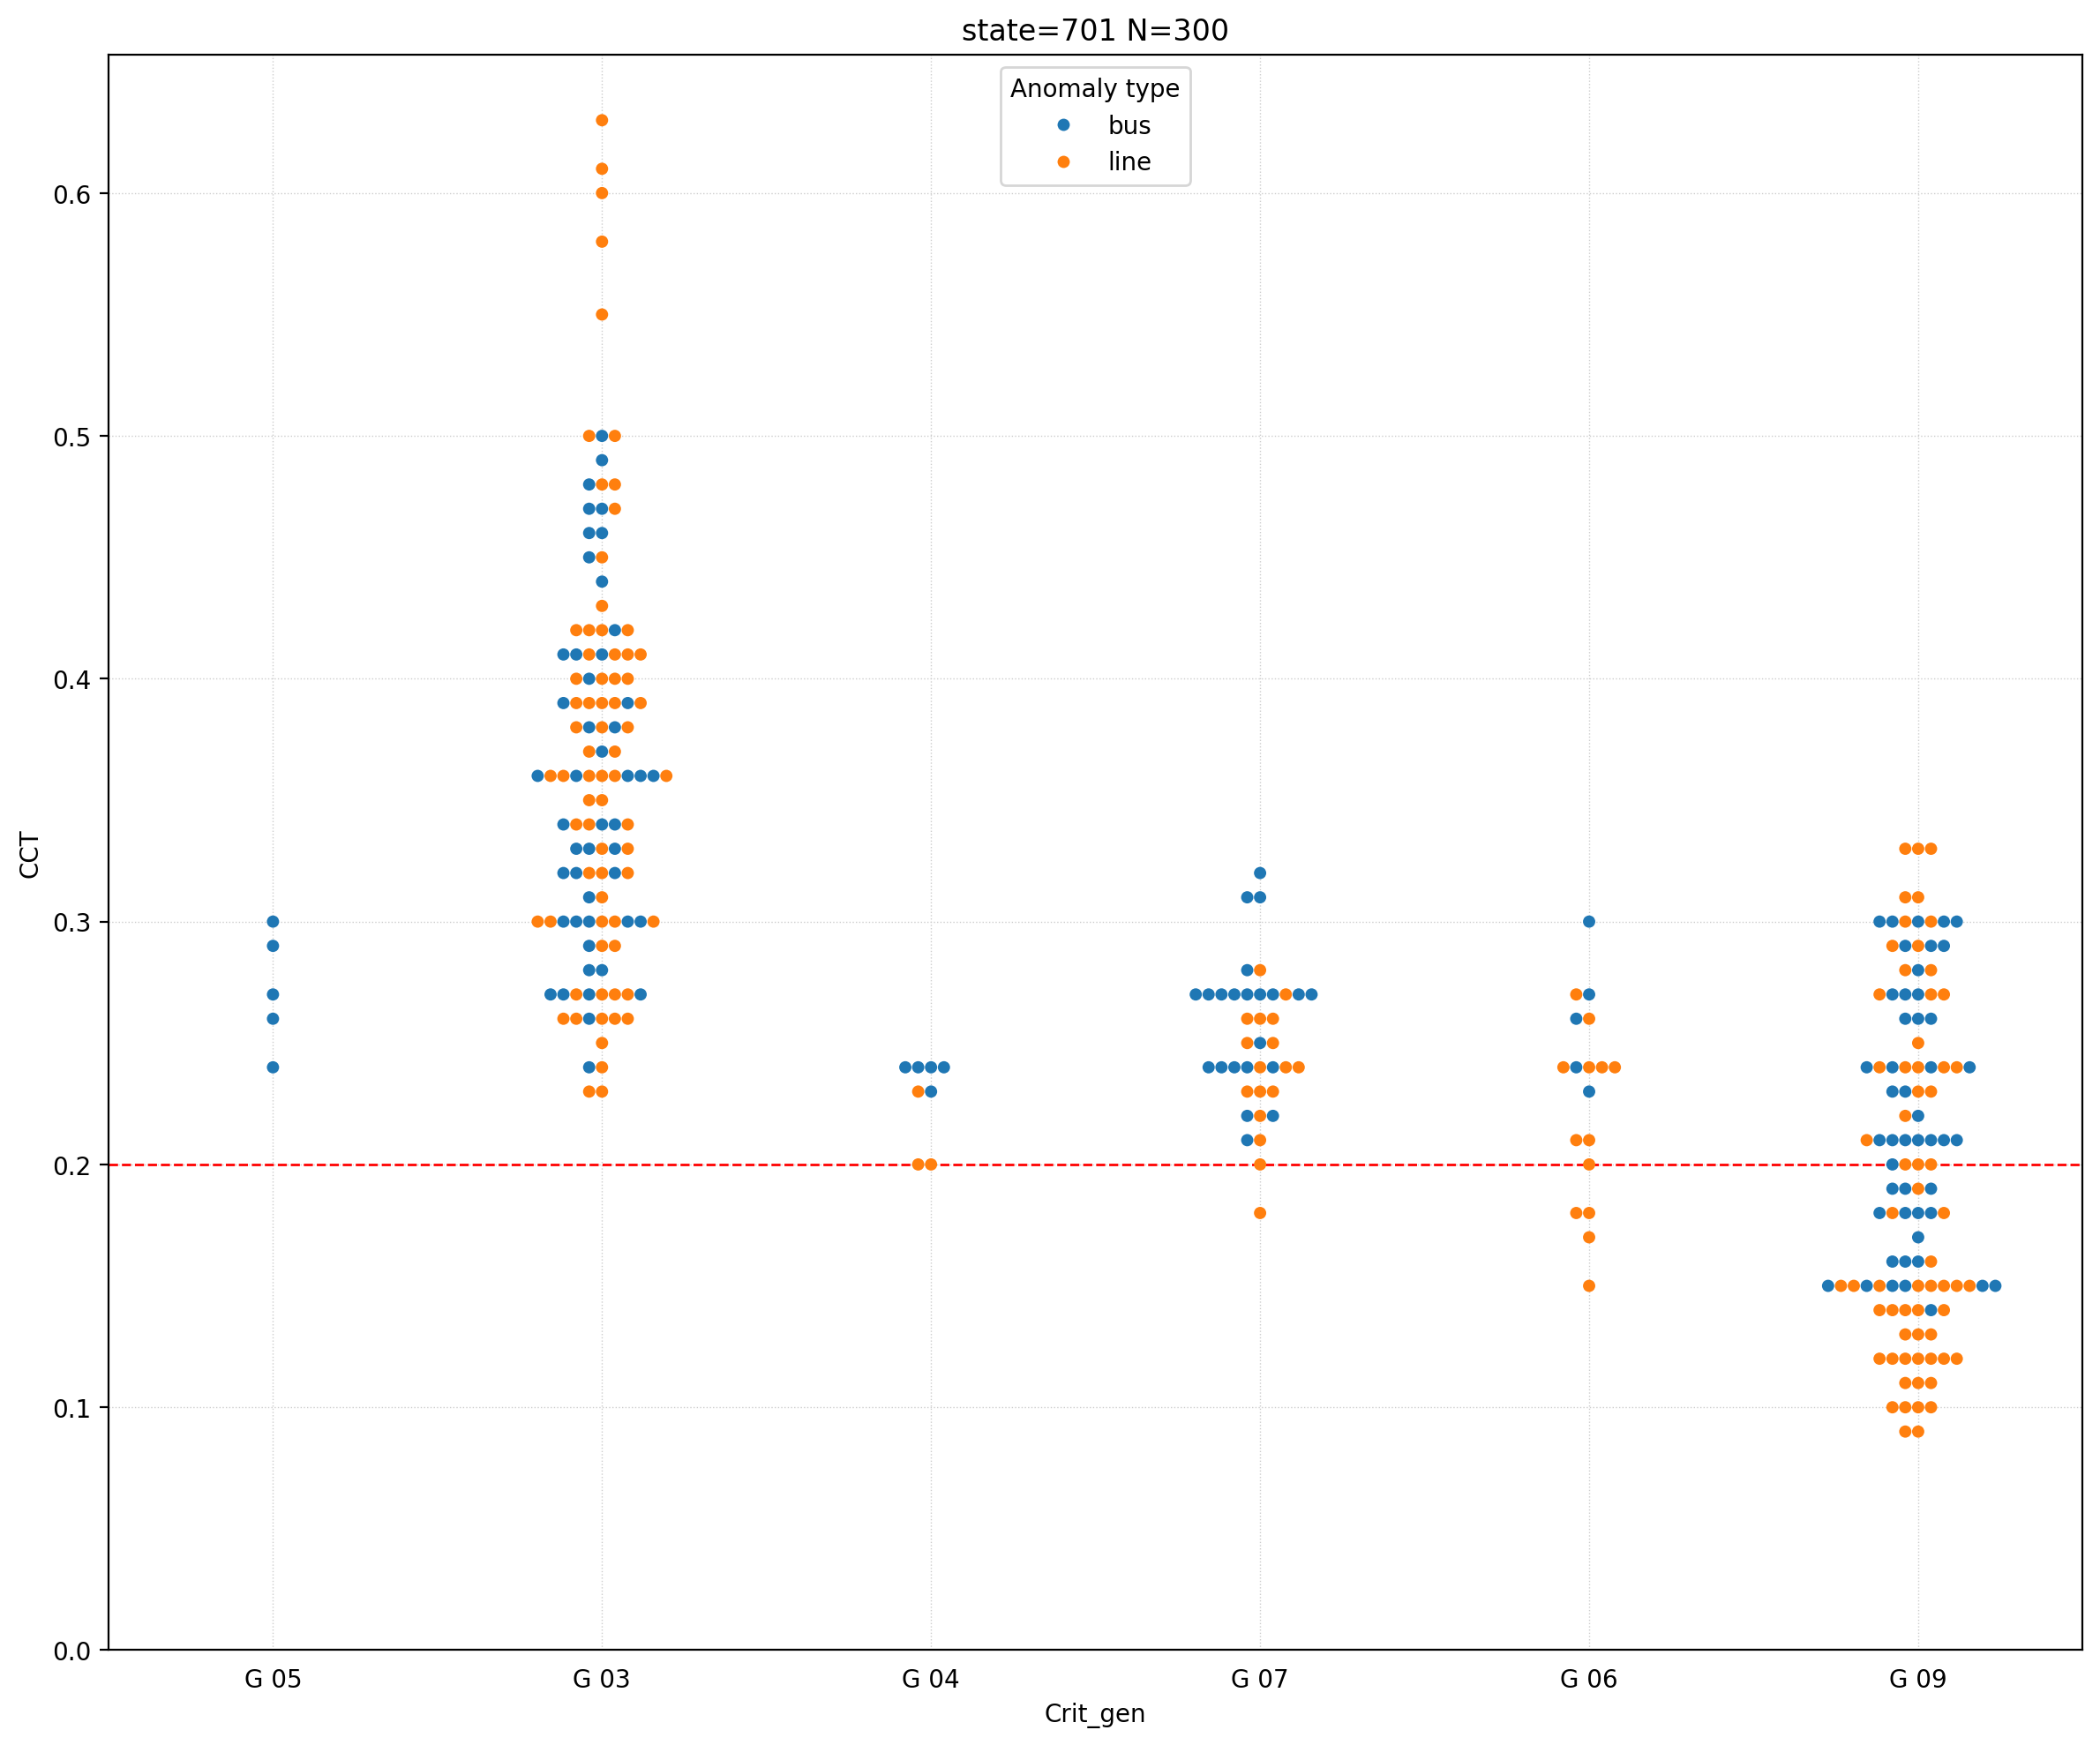

In [ ]:
state_id = 701
state_sample_id = 0

n_samples = 300  # total number of samples for plotting

# in trainset we remove evaluation sample's grid state to avoid potential data leakage.
trainset_mask = df["state"] != state_id

knn = neighbors.NearestNeighbors(
    n_neighbors=n_samples,
    metric="euclidean",
)

with joblib.parallel_backend("loky", n_jobs=joblib.cpu_count()):
    with TimeIt("Feature transformation time"):
        X_train = encoder.transform(df[trainset_mask])
        X_test = encoder.transform(df[~trainset_mask].iloc[[state_sample_id]])

    assert X_test.shape[0] == 1, X_test.shape

    with TimeIt("kNN fit time"):
        knn.fit(X_train)

    with TimeIt("kNN estimate time"):
        distances, indices = knn.kneighbors(X_test, n_neighbors=n_samples, return_distance=True)


# Store distance between already seen samples and a new sample.
neigh = df[trainset_mask].iloc[indices.flatten()].copy()
neigh["distance"] = distances.flatten()


# More verbose type of anomaly used for figures
# sc_types = {0: "zbiralka (izzveni)", 1: "daljnovod"}
sc_types = {0: "bus", 1: "line"}
neigh["Type"] = neigh["Type"].map(sc_types).astype("category")

assert len(neigh) == n_samples, len(neigh)


f, ax = plt.subplots(figsize=(12, 10))
ax.set_title(f"state={state_id} N={len(neigh)}")

# Compute generator order (x-axis) based on minimum CCT per Crit_gen
sorted_order = neigh.groupby("Crit_gen", observed=True)["CCT"].min().sort_values(ascending=False).index

# Add horizontal threshold line
ax.axhline(y=CCT_THRESHOLD, color="red", linestyle="--", linewidth=1)

sns.swarmplot(x="Crit_gen", y="CCT", hue="Type", data=neigh, order=sorted_order, ax=ax, edgecolor="none")

ax.set_ylim(0, None)
ax.grid(which="major", axis="both", linestyle=":", linewidth=0.5, color="0.8")
ax.legend(loc="upper center", title="Anomaly type")
ax.tick_params(axis="x", which="both", bottom=False)

f.tight_layout()
plt.show()

In [ ]:
# Interactive version of UI
import plotly.express as px

fig = px.strip(neigh, x="Crit_gen", y="CCT", color="Type", hover_data=["Location"])
# sns.swarmplot(x="Crit_gen", y="CCT", hue="Type", data=neigh, order=sorted_order, ax=ax, edgecolor="none")
# Compute generator order (x-axis) based on minimum CCT per Crit_gen
sorted_order = neigh.groupby("Crit_gen", observed=True)["CCT"].min().sort_values(ascending=False).index

fig.update_xaxes(categoryorder="array", categoryarray=sorted_order)
fig.update_xaxes()

In [ ]:
with joblib.parallel_backend("loky", n_jobs=joblib.cpu_count()):
    distances, indices = knn.kneighbors(X_test, n_neighbors=X_train.shape[0], return_distance=True)

# Store distance between already seen samples and a new sample.
neigh = df[trainset_mask].iloc[indices.flatten()].copy()
neigh["distance"] = distances.flatten()

# More verbose type of anomaly used for figures
sc_types = {0: "zbiralka (izzveni)", 1: "daljnovod"}
neigh["Type"] = neigh["Type"].map(sc_types).astype("category")

# Is the state stable?
neigh["is_stable"] = neigh["CCT"] > CCT_THRESHOLD

neigh = neigh.sort_values(by="distance")[["state", "Location", "Type", "Crit_gen", "CCT", "is_stable", "distance"]]

In [ ]:
# Identical distance is because different anomaly was simulated on the same grid state.
# This won't be a case in real-world data.
neigh

,state,Location,Type,Crit_gen,CCT,is_stable,distance
1166290,11791,Bus 18,zbiralka (izzveni),G 09,0.29,True,5.898322
599932,11791,Bus 22,zbiralka (izzveni),G 07,0.24,True,5.898322
11791,11791,Bus 10,zbiralka (izzveni),G 03,0.28,True,5.898322
33574,11791,Line 10 - 13,daljnovod,G 03,0.27,True,5.898322
55357,11791,Line 10 - 11,daljnovod,G 03,0.27,True,5.898322
...,...,...,...,...,...,...,...
102372,15240,Bus 20,zbiralka (izzveni),G 05,1.14,True,49.606531
37023,15240,Line 10 - 13,daljnovod,G 03,1.81,True,49.606531
233070,15240,Line 02 - 25,daljnovod,G 08,1.89,True,49.606531
15240,15240,Bus 10,zbiralka (izzveni),G 03,1.65,True,49.606531


<Axes: ylabel='Frequency'>

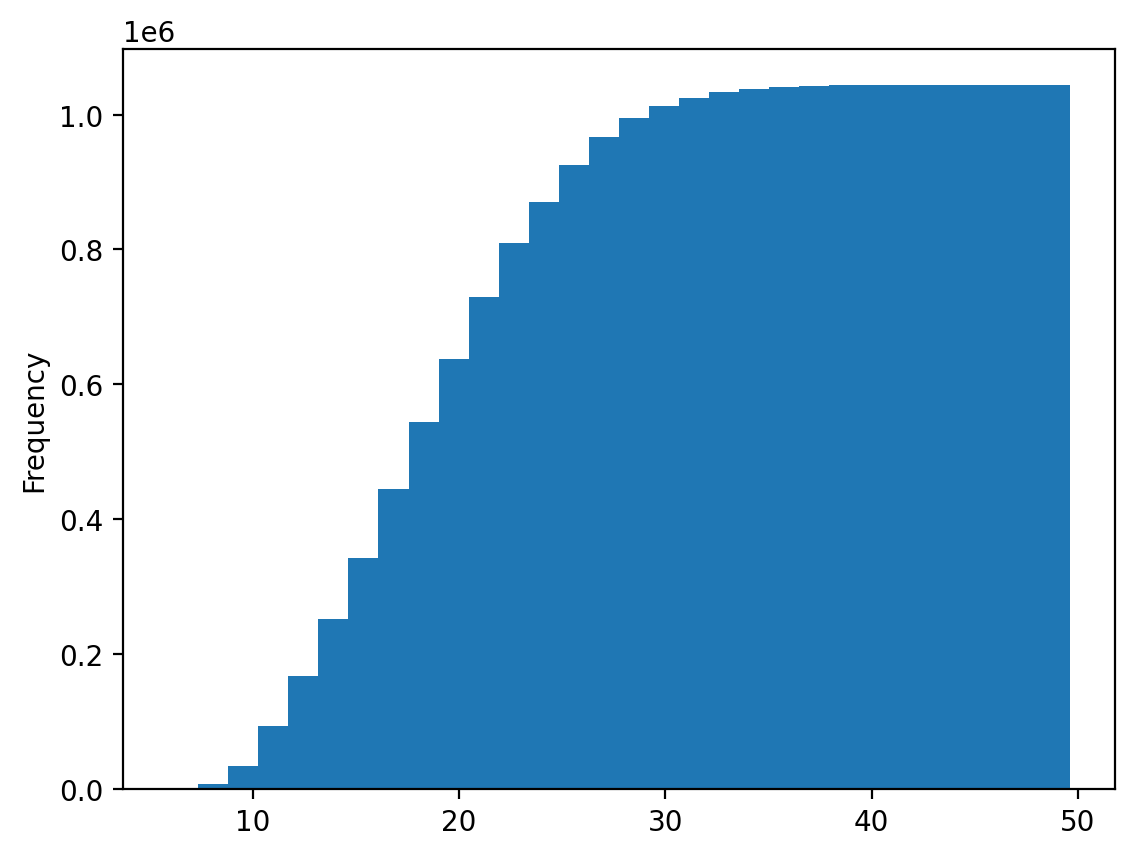

In [ ]:
# Distribution of distances from observed state
neigh["distance"].plot.hist(bins=30, cumulative=True)

In [ ]:
n = 300

for gen, subset in neigh.head(n).groupby("Crit_gen"):
    n_total = len(subset)
    n_stable = subset.is_stable.sum()
    if n_total > 0:
        print(f'Generator "{gen}" stability likelyhood: {n_stable}/{n_total}  ({n_stable / n_total * 100.0:.1f}%)')
    else:
        print(f'Generator "{gen}" stability likelyhood: No Records')

Generator "G 03" stability likelyhood: 120/120  (100.0%)
Generator "G 04" stability likelyhood: 3/5  (60.0%)
Generator "G 05" stability likelyhood: 5/5  (100.0%)
Generator "G 06" stability likelyhood: 13/19  (68.4%)
Generator "G 07" stability likelyhood: 38/40  (95.0%)
Generator "G 09" stability likelyhood: 53/111  (47.7%)


In [ ]:
# The most hazardous locations (n=500)
n = 500

neigh["Location"].head(n).value_counts()

Location
Line 22 - 23    13
Bus 02           9
Bus 04           9
Bus 05           9
Bus 06           9
Bus 07           9
Bus 08           9
Bus 10           9
Bus 13           9
Bus 14           9
Bus 18           9
Bus 21           9
Bus 22           9
Bus 23           9
Bus 25           9
Bus 26           9
Bus 27           9
Bus 28           9
Bus 29           9
Line 01 - 02     9
Line 02 - 03     9
Line 02 - 25     9
Line 03 - 04     9
Line 03 - 18     9
Line 04 - 05     9
Line 04 - 14     9
Line 05 - 06     9
Line 06 - 07     9
Line 06 - 11     9
Line 07 - 08     9
Line 08 - 09     9
Line 10 - 11     9
Line 10 - 13     9
Line 13 - 14     9
Line 14 - 15     9
Line 16 - 17     9
Line 16 - 24     9
Line 17 - 27     9
Line 21 - 22     9
Line 23 - 24     9
Line 25 - 26     9
Line 26 - 27     9
Line 26 - 28     9
Line 26 - 29     9
Line 28 - 29     9
Bus 03           8
Bus 11           8
Bus 16           8
Bus 17           8
Bus 20           8
Bus 24           8
Line 05 - 08     8
Lin